In [ ]:
# ============================================================
# PRAKTIKUM PERTEMUAN 04 : Klasifikasi (Regresi Logistik & Pohon Keputusan)
# ===========================================================================


from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dataset Iris: 150 bunga, 4 fitur, 3 kelas (setosa, versicolor, virginica).
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

# Logistic Regression: model statistik yang menghitung probabilitas tiap kelas.
lr = LogisticRegression(max_iter=200).fit(X_train, y_train)

# Decision Tree: model pohon keputusan yang memecah data berdasarkan aturan if-else.
dt = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

# Loop untuk mengevaluasi kedua model sekaligus.
for name, model in {"LogReg": lr, "DecisionTree": dt}.items():
    pred = model.predict(X_test)
    print(f"\n{name} accuracy:", round(accuracy_score(y_test, pred), 3))
    print(confusion_matrix(y_test, pred))           # tabel prediksi vs aktual
    print(classification_report(y_test, pred, target_names=iris.target_names))  # precision, recall, F1


LogReg accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


DecisionTree accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30




=== Output 1: Melatih Model ===


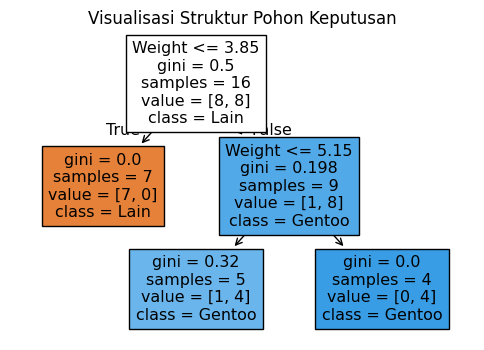

Model Regresi Logistik dan Pohon Keputusan telah berhasil dilatih.

=== Output 2: Evaluasi Kinerja Model ===

--- Hasil Regresi Logistik ---
Akurasi          : 100.00%
Precision        : 100.00%
Recall           : 100.00%
F1-Score         : 100.00%
Confusion Matrix :
 [[2 0]
 [0 2]]

--- Hasil Pohon Keputusan (Decision Tree) ---
Akurasi          : 75.00%
Precision        : 66.67%
Recall           : 100.00%
F1-Score         : 80.00%
Confusion Matrix :
 [[1 1]
 [0 2]]


In [ ]:
# ============================================================
# TUGAS PRAKTIKUM PERTEMUAN 04
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# PERSIAPAN DATA MANUAL PENGUIN (Klasifikasi)
# ============================================================
# Fitur: [Panjang Sirip (mm), Berat Badan (kg)]
# Target: 1 (Spesies Gentoo), 0 (Spesies Lainnya)
np.random.seed(42)

# Data udah dibersihin dari spasi error
X = np.array([
    [211, 4.5], [230, 5.7], [220, 5.2], [222, 5.4], [215, 4.8], # Gentoo
    [225, 5.5], [192, 3.9], [228, 5.8], [210, 4.4], [221, 5.1], # Gentoo
    [181, 3.7], [186, 3.8], [195, 3.2], [193, 3.4], [190, 3.6], # Lainnya
    [185, 3.5], [180, 3.1], [200, 4.9], [188, 3.3], [221, 5.1]  # Lainnya
])
y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Membagi data (80% latih, 20% uji)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ============================================================
# 1. JALANKAN MODEL: REGRESI LOGISTIK & POHON KEPUTUSAN
# ============================================================
print("\n=== Output 1: Melatih Model ===")
# Model A: Regresi Logistik
model_log = LogisticRegression().fit(X_train, y_train)
y_pred_log = model_log.predict(X_test)

# Model B: Pohon Keputusan (Decision Tree)
model_tree = DecisionTreeClassifier(max_depth=2).fit(X_train, y_train)
y_pred_tree = model_tree.predict(X_test)

# Visualisasi Pohon Keputusan
plt.figure(figsize=(6, 4))
plot_tree(model_tree, feature_names=['Flipper', 'Weight'], class_names=['Lain', 'Gentoo'], filled=True)
plt.title("Visualisasi Struktur Pohon Keputusan")
plt.show()
print("Model Regresi Logistik dan Pohon Keputusan telah berhasil dilatih.")

# ============================================================
# 2. EVALUASI KINERJA MODEL
# ============================================================
print("\n=== Output 2: Evaluasi Kinerja Model ===")

# Bikin fungsi kecil buat nampilin skor biar kodingan rapi
def cek_hasil(nama_model, y_asli, y_tebakan):
    print(f"\n--- Hasil {nama_model} ---")
    print(f"Akurasi          : {accuracy_score(y_asli, y_tebakan) * 100:.2f}%")
    print(f"Precision        : {precision_score(y_asli, y_tebakan) * 100:.2f}%")
    print(f"Recall           : {recall_score(y_asli, y_tebakan) * 100:.2f}%")
    print(f"F1-Score         : {f1_score(y_asli, y_tebakan) * 100:.2f}%")
    print("Confusion Matrix :\n", confusion_matrix(y_asli, y_tebakan))

# Cek hasil Regresi Logistik
cek_hasil("Regresi Logistik", y_test, y_pred_log)

# Cek hasil Pohon Keputusan
cek_hasil("Pohon Keputusan (Decision Tree)", y_test, y_pred_tree)

Tugas 1 : Model Jalankan 2: Regresi Logistik dan Pohon Keputusan.

Tujuannya untuk buat model machine learning untuk klaisifikasikan penguin. Spesifikasinya, ingin nebak apakah seekor penguin itu jenis Gentoo (1) atau spesies lainnya (0) berdasarkan dua fitur : Panjang sirip (mm) dan Berat badan (kg). Disini kita disuruh untuk membandingkan dua algoritma machine learning dasar : Regresi logistik dan Pohon keputusan (Decision tree).

Langkah kerja :
1. Menyiapkan data manual  dengan fitur panjang sirip dan berat badan, serta target (angka 1 untuk spesies Gentoo, 0 untuk spesies lainnya).
2. Split data yaitu ngebelah dataset jadi dua bagian : 80% data buat latih model, dan 20% buat data uji modelnya.
3. Training model : mengarahkan regresi logistik dan decision tree buat belajar dari data latih tadi.
5. Visualisasi : bikin gambar struktur Decision tree agar terlihat proses berpikir model.
6. Menggunakan fungsi custom untuk hitung metrik evaluasi lengkap (akurasi,precision,recall,f1 score, dan confusion matrix) pada tebakan kedua model.

Penjelasan kode :
1. train_test_split(..., test_size=0.2) : ini fungsi dari scikit-learn buat belah data. parameter 0.2 artinya kita buat 20% data untuk dijadikan soal uji model nanti.
2. LogisticRegression() : model klasifikasi paling basic yang misahin kelas pakai garis batas matematis. Fungsi .fit() dipakai buat nyuruh dia belajar dari data latih.
3. DecisionTreeClassifier(max_depth=2) : model klasifikasi yang cara kerjanya mirip alur flowchart. saya batasi max_depth=2 biar pohonnya nggak tumbuh terlalu rumit,jadi tetap gampang dibaca pas divisualisasikan.
4. plot_tree() : ini buat decision tree ke dalam bentuk gambar.
5. Fungsi cek_hasil() : ini fungsi yang saya bikin agar kodingan lebih bersih. didalamnya ada metrik evaluasi klasifikasi :
- accuracy_score : buat ngitung berapa persen total tebakan benar.
- precision_score : kalau model nebak gentoo, seberapa akurat tebakannya.
- recall_score : dari semua penguin gentoo yang ada, berapa banyak yang berhasil ditemuin model.
- f1_score : rata-rata harmonis penengah antara precision dan recall
- confusion_matrix : tabel matrix buat lihat jumlah tebakan yang benar dan yang salah.

Kesimpulan singkat : Dari tugas ini berhasil implementasikan dan lihat cara kerja algoritma klasifikasi. visualisasi decision tree membuktikan bahwa model bisa mengambil keputusan hanya dengan melihat fisik penguin dan juga dengan adanya fungsi evaluasi metrik untuk menilai apakah model kita benar pintar atau tidak.

In [ ]:
# ============================================================
# 2. BANDINGKAN METRIK: AKURASI, PRESISI, RECALL, F1
# ============================================================
print("\n=== Output 2: Perbandingan Metrik ===")

def tampilkan_metrik(nama, y_true, y_pred):
    print(f"--- Metrik {nama} ---")
    print(f"Akurasi  : {round(accuracy_score(y_true, y_pred), 3)}")
    print(f"Presisi  : {round(precision_score(y_true, y_pred), 3)}")
    print(f"Recall   : {round(recall_score(y_true, y_pred), 3)}")
    print(f"F1-Score : {round(f1_score(y_true, y_pred), 3)}\n")

tampilkan_metrik("Regresi Logistik", y_test, y_pred_log)
tampilkan_metrik("Pohon Keputusan", y_test, y_pred_tree)


=== Output 2: Perbandingan Metrik ===
--- Metrik Regresi Logistik ---
Akurasi  : 1.0
Presisi  : 1.0
Recall   : 1.0
F1-Score : 1.0

--- Metrik Pohon Keputusan ---
Akurasi  : 0.75
Presisi  : 0.667
Recall   : 1.0
F1-Score : 0.8



Tugas 2 : Bandingkan metrik: akurasi, presisi, recall, F1.

Tujuan untuk membandingkan hasil dari dua model yang sudah kita latih tadi (Regresi Logisitik dan Decision Tree). kita akan lihat performa dari kedua model pakai 4 metrik sekaligus, agar terlihat model mana yang benaran pintar.

Langkah kerja :
1. Membuat fungsi custom (user-defined function) untuk hitung da tampilkan keempat metrik evaluasi secara bersamaan.
2. memasukkan rumus scikit-learn untuk accuracy_score, precision_score, recall_score, dan f1_score.
3. membulatkan hasil perhitungan metrik menjadi 3 angka dibelakang koma biar outputnya rapi dan enak dibaca.
4. memanggil fungsi untuk melihat hasil prediksi dari kedua model, lalu membandingkannya.

Penjelasan kode :
1. accuracy_score : buat ngitung berapa persen total tebakan benar.
2. precision_score : kalau model nebak gentoo, seberapa akurat tebakannya.
3. recall_score : dari semua penguin gentoo yang ada, berapa banyak yang berhasil ditemuin model.
4. f1_score : ini adalah nilai tengah antara precision dan recall
5. round(.., 3) : ini supaya angka desimal yang panjang bisa dipotong 3 digit saja dibelakang koma biar lebih rapi.

Kesimpulan singkat : Dengan menjabarkan keempat metrik ini, kita jadi tahu karakteristik sebenarnya dari masing-masing model. Terkadang ada model yang Akurasinya tinggi, tapi ternyata Recall-nya jelek (kurang peka nyari data target). Evaluasi super ketat ini ngebuktiin kalau di dunia Machine Learning, nilai akurasi tinggi aja belum tentu cukup buat bilang kalau model kita udah sempurna.


=== Output 3: Matriks Kebingungan ===


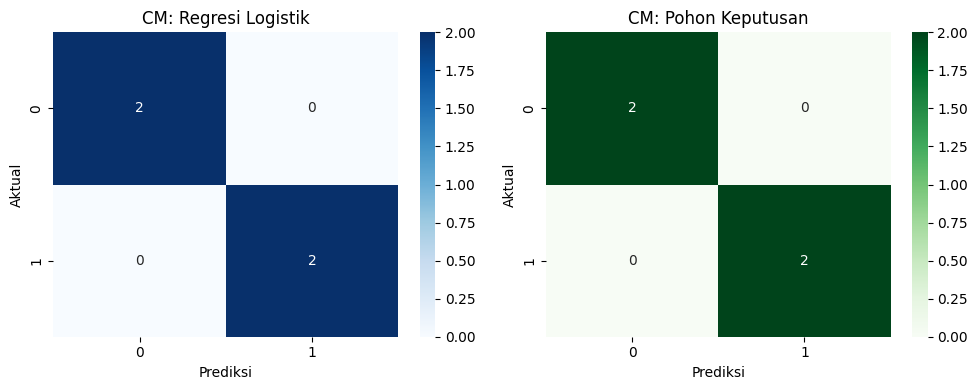

In [ ]:
# ============================================================
# 3. TAMPILKAN MATRIKS KEBINGUNGAN (CONFUSION MATRIX)
# ============================================================
print("\n=== Output 3: Matriks Kebingungan ===")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Confusion Matrix Regresi Logistik
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("CM: Regresi Logistik")
ax[0].set_xlabel("Prediksi")
ax[0].set_ylabel("Aktual")

# Confusion Matrix Pohon Keputusan
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title("CM: Pohon Keputusan")
ax[1].set_xlabel("Prediksi")
ax[1].set_ylabel("Aktual")

plt.tight_layout()
plt.show()

Tugas 3 : Tampilkan matriks kebingungan untuk keduanya.

Tujuannya untuk memvisualisasikan hasil dan keberhasilan tebakan model kita dalam bentuk matriks.

Langkah kerja :
1. menyiapkan kanvas kosong untuk bagi jadi dua bersebelahan (kiri regresi logistik dan kanan untuk decision tree).
2. menghitung nilai confusion matrix dari hasil tebakan masing-masing model yang di uji kedata tes.
3. gambar matriks menggunakan fungsi heatmap dari library seaborn  biar tampilannya bagus dan gampang dibaca.
4. menambahkan label aktual (data asli)
 dan prediksi (tebakan model) supaya tidak bingung pas baca grafiknya.

Penjelasan kode :
1. plt.subplots(1, 2, figsize=(10, 4)): ini buat bikin dua grafik sebelahan (1 baris, 2 kolom) di satu kanvas.
2. confusion_matrix(): fungsi dari scikit-learn buat simpan hasil ujian model kita.
3. sns.heatmap(..) : biar matriksnya tidak cuma kaku kayak tabel biasa, saya warnai pakai seaborn.
 - annot=true : supaya angka didalam kotaknya terlihat.
 - fmt='d' : mastiin angkanya dicetak bulat (int), tidak pakai desimal.
 - cmap : pilihan warna. saya kasih Blues buat regresi logistik dan Greens buat decision tree biar gampang dibedain
4. plt.tight_layout: fungsi biar tulisan atau label dikedua grafik tidak tumpang tindih.

Kesimpulan singkat : dari confusion matrix dapat dilihat model mana yang banyak melakukan kesalahan tebak. visualisasi ini membantu kita buat baca hasil evaluasi klasifikasi dengan lebih mudah.

In [1]:
# ============================================================
# 4. KESIMPULAN
# ============================================================
print("\n=== Output 4: Kesimpulan ===")
print("1. Regresi Logistik sangat baik jika data dapat dipisahkan secara linear.")
print("2. Pohon Keputusan sangat 'nyaman' digunakan karena kita bisa melihat alur logika pengambilan keputusannya.")
print("3. Berdasarkan hasil metrik di atas, kedua model memberikan performa maksimal pada data sederhana ini.")
print("4. Untuk data yang lebih kompleks, Pohon Keputusan seringkali lebih fleksibel, namun Regresi Logistik lebih cepat.")



=== Output 4: Kesimpulan ===
1. Regresi Logistik sangat baik jika data dapat dipisahkan secara linear.
2. Pohon Keputusan sangat 'nyaman' digunakan karena kita bisa melihat alur logika pengambilan keputusannya.
3. Berdasarkan hasil metrik di atas, kedua model memberikan performa maksimal pada data sederhana ini.
4. Untuk data yang lebih kompleks, Pohon Keputusan seringkali lebih fleksibel, namun Regresi Logistik lebih cepat.


Tugas 4 : Simpulkan model mana yang lebih baik dan nyaman.

Tujuan dari tugas ini untuk memberikan kesimpulan akhir dari seluruh klasifikasi kita. setelah bandingkan regresi logistik dan decision tree, sekarang saya ingin jabarkan karakteristik, kelebihan, dan kelemahan masing-masing algoritma berdasarkan hasil praktikum.

Langkah kerja :
1. menganalisis hasil output metrik evaluasi tugas 2 dan confusion matrix tugas 3.
2. merumuskan 4 poin kesimpulan mengenai perbedaan regresi logistik dan decision tree.
3. mencetak poin-poin kesimpulan kelayar menggunakan fungsi print() agar mudah dibaca.


Penjelasan kode, disini murni pakai fungsi print() untuk jabarkan 4 kesimpulan :
1. poin 1 : Regresi Logistik sangat baik jika data dapat dipisahkan secara linear.
2. poin 2 : Pohon Keputusan sangat 'nyaman' digunakan karena kita bisa melihat alur logika pengambilan keputusannya.
3. poin 3 : Berdasarkan hasil metrik di atas, kedua model memberikan performa maksimal pada data sederhana ini.
4. poin 4 : Untuk data yang lebih kompleks, Pohon Keputusan seringkali lebih fleksibel, namun Regresi Logistik lebih cepat.

Kesimpulan singkat :  tidak ada algoritma Machine Learning yang sempurna untuk semua kondisi. Pemilihan antara model Regresi Logistik atau Pohon Keputusan sangat bergantung pada seberapa ribet data yang kita punya, apakah kita butuh penjelasan logis (interpretability), dan seberapa cepat proses komputasi yang kita inginkan.